In [1]:
import  numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

#DATASET

CASH-IN: is the process of increasing the balance of
account by paying in cash to a merchant.

CASH-OUT: is the opposite process of CASH-IN, it
means to withdraw cash from a merchant which decreases
the balance of the account.

DEBIT: is similar process than CASH-OUT and involves sending the money from the mobile money service
to a bank account.

PAYMENT: is the process of paying for goods or services to merchants which decreases the balance of the account and increases the balance of the receiver.

TRANSFER: is the process of sending money to another user of the service through the mobile money platform

In [91]:
df = pd.read_csv("AIML Dataset.csv")

In [97]:
df = df.sample(frac=0.3, random_state=42)

In [98]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
4598081,328,PAYMENT,14189.51,C1356511043,0.00,0.00,M1392805103,0.00,0.00,0,0
1384380,138,PAYMENT,15240.04,C1065349511,0.00,0.00,M1927004926,0.00,0.00,0,0
462527,19,PAYMENT,604.25,C1024666185,228485.00,227880.75,M292387302,0.00,0.00,0,0
161964,12,CASH_OUT,477389.21,C412757352,0.00,0.00,C894315519,517257.87,435402.79,0,0
6008947,439,CASH_IN,356546.50,C126916680,1946815.39,2303361.89,C1669684987,2040513.51,1683967.01,0,0


Explanatory DATA ANALYSIS

In [99]:
df.info()

<class 'pandas.DataFrame'>
Index: 190879 entries, 4598081 to 5838398
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            190879 non-null  int64  
 1   type            190879 non-null  str    
 2   amount          190879 non-null  float64
 3   nameOrig        190879 non-null  str    
 4   oldbalanceOrg   190879 non-null  float64
 5   newbalanceOrig  190879 non-null  float64
 6   nameDest        190879 non-null  str    
 7   oldbalanceDest  190879 non-null  float64
 8   newbalanceDest  190879 non-null  float64
 9   isFraud         190879 non-null  int64  
 10  isFlaggedFraud  190879 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 22.7 MB


In [100]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [101]:
df['isFraud'].value_counts()  #amount of fraud in dataset 

isFraud
0    190641
1       238
Name: count, dtype: int64

In [102]:
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    190879
Name: count, dtype: int64

In [103]:
df.isnull().sum() #no null value detected in dataset

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [104]:
df.shape  #6362620 no of transactions

(190879, 11)

In [105]:
(df["isFraud"].value_counts()[1]/df.shape[0]) * 100 #0.13 percent of data is fraud

np.float64(0.12468631960561402)

Text(0, 0.5, 'Count')

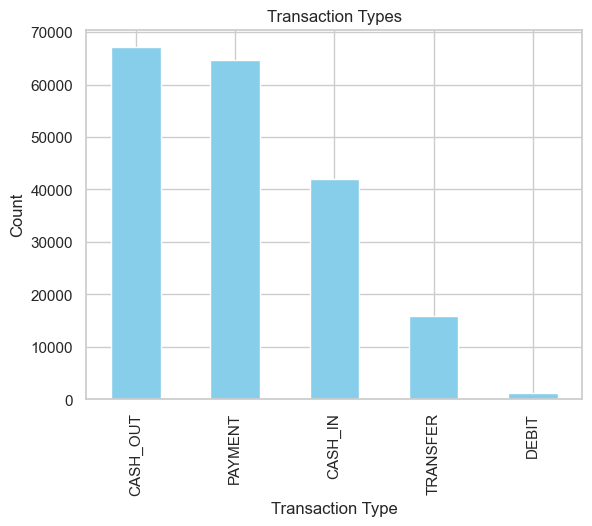

In [106]:
df["type"].value_counts().plot(kind="bar", title="Transaction Types", color='skyblue')
plt.xlabel("Transaction Type")
plt.ylabel("Count")

Text(0, 0.5, 'Fraud Rate')

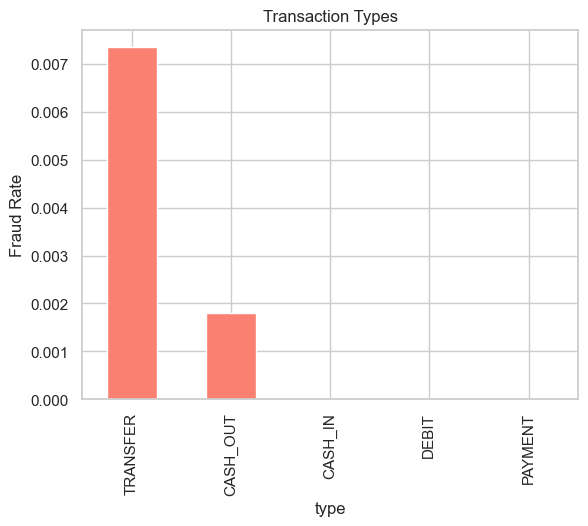

In [107]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Transaction Types", color='salmon')
plt.ylabel("Fraud Rate")

In [108]:
fraud_by_type #from above chart fraud only in TRANSFER and CASH_OUT

type
TRANSFER    0.007346
CASH_OUT    0.001803
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

In [109]:
df["amount"].describe().astype(int)  #NO negative value of amount

count      190879
mean       180114
std        606928
min             0
25%         13340
50%         74920
75%        209482
max      48391417
Name: amount, dtype: int64

Text(0.5, 0, 'Log(Amount+1)')

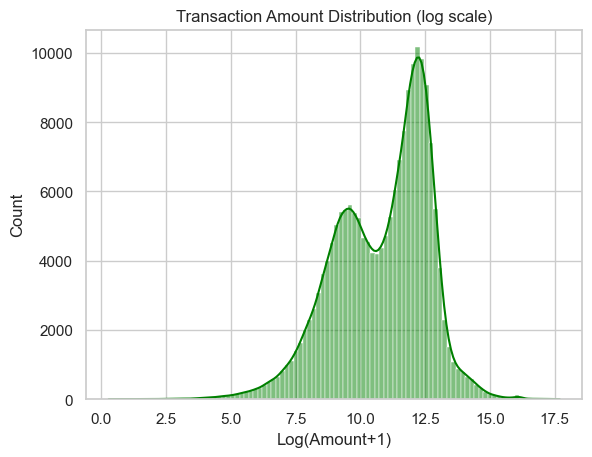

In [110]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde= True, color = "green")
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("Log(Amount+1)") # +1 for min amt = 0 log(0) not  defined

Text(0.5, 1.0, 'Amount vs isFraud (Filtered Under 50k)')

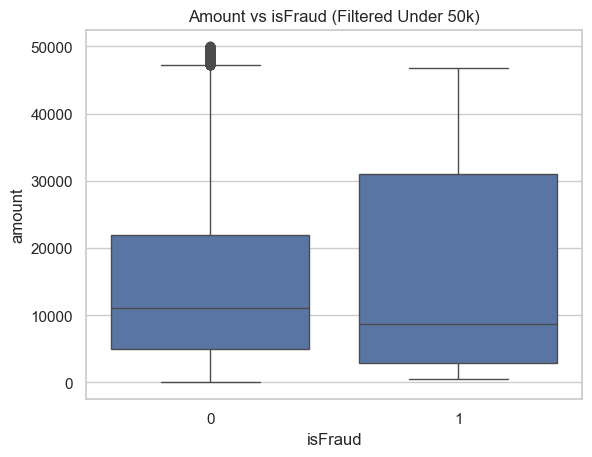

In [111]:
sns.boxplot(data=df[df["amount"] < 50000], x = "isFraud", y="amount")
plt.title("Amount vs isFraud (Filtered Under 50k)")
#High fraud rate on higher amounts

In [112]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [113]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["amount"] - df["newbalanceOrig"]  #difference old and new balance of source account
df["balanceDiffDest"] = df["newbalanceDest"] - df["amount"] - df["oldbalanceDest"] #difference old and new balance of target account

In [114]:
(df["balanceDiffOrig"] < 0).sum()

np.int64(156299)

In [115]:
(df["balanceDiffDest"] < 0).sum()

np.int64(126066)

In [116]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
4598081,328,PAYMENT,14189.51,C1356511043,0.0,0.0,M1392805103,0.0,0.0,0,0,-14189.51,-14189.51
1384380,138,PAYMENT,15240.04,C1065349511,0.0,0.0,M1927004926,0.0,0.0,0,0,-15240.04,-15240.04


Text(0, 0.5, 'Number of frauds')

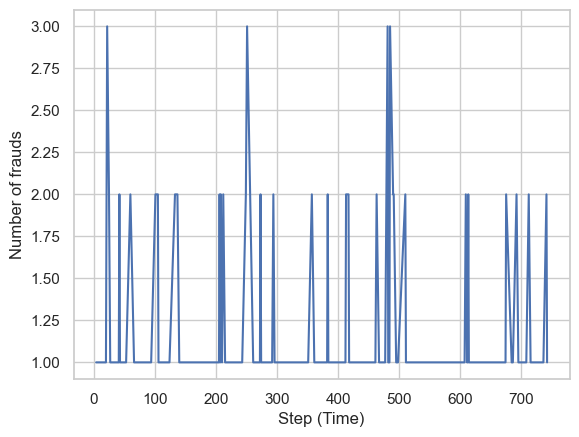

In [117]:
fraud_per_step = df[df["isFraud"]==1]["step"].value_counts().sort_index()
plt.plot(fraud_per_step.index, fraud_per_step.values, label="Frauds per step")
plt.xlabel("Step (Time)")
plt.ylabel("Number of frauds")
#step feature is not  very high varying factor over fraud

In [118]:
df.drop(columns = "step", inplace=True) #inplace i means change effective in original dataframe

In [119]:
df.head(2)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
4598081,PAYMENT,14189.51,C1356511043,0.0,0.0,M1392805103,0.0,0.0,0,0,-14189.51,-14189.51
1384380,PAYMENT,15240.04,C1065349511,0.0,0.0,M1927004926,0.0,0.0,0,0,-15240.04,-15240.04


In [120]:
top_senders = df["nameOrig"].value_counts().head(10)
top_senders

nameOrig
C66902779      2
C1406061613    2
C909999115     2
C1123917143    2
C1356511043    1
C1065349511    1
C1024666185    1
C412757352     1
C126916680     1
C1738194930    1
Name: count, dtype: int64

In [121]:
top_receivers = df["nameDest"].value_counts().head(10)
top_receivers


nameDest
C875290750     7
C345507865     7
C675520606     7
C1815509870    7
C1636786811    7
C1754571129    6
C599726537     6
C1633208957    6
C1379289710    6
C1040847151    6
Name: count, dtype: int64

In [122]:
fraud_users = df[df["isFraud"]==1]["nameOrig"].value_counts().head(10) #Fraud Users
fraud_users

nameOrig
C692748109     1
C1229699193    1
C1750640057    1
C1410879349    1
C676285921     1
C894359747     1
C884840595     1
C560583390     1
C958487787     1
C1397090856    1
Name: count, dtype: int64

In [123]:
fraud_types = df[df["type"].isin(["TRANSFER","CASH_OUT"])]

In [124]:
fraud_types["type"].value_counts()

type
CASH_OUT    67100
TRANSFER    15927
Name: count, dtype: int64

Text(0.5, 1.0, 'Fraud Distribution in transfer and cash_out')

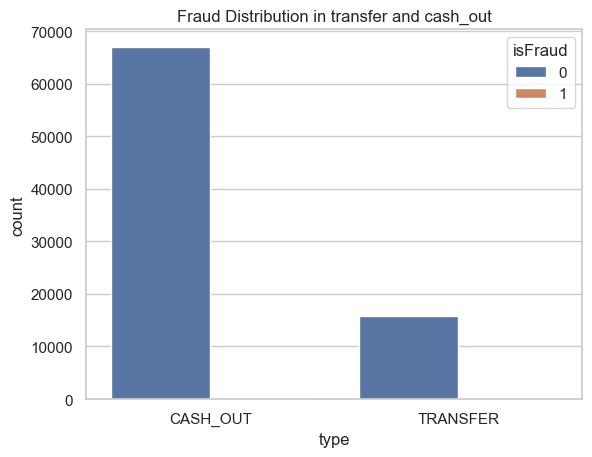

In [125]:
sns.countplot(data=fraud_types, x="type", hue = "isFraud")
plt.title("Fraud Distribution in transfer and cash_out")

In [126]:
sample_df = df.sample(100000, random_state=42)
corr =  sample_df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()

corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.004304,-0.007655,0.331262,0.489777,0.062718
oldbalanceOrg,-0.004304,1.000000,0.998978,0.064005,0.040307,0.005512
newbalanceOrig,-0.007655,0.998978,1.000000,0.065417,0.040041,-0.009926
oldbalanceDest,0.331262,0.064005,0.065417,1.000000,0.978127,-0.006184
newbalanceDest,0.489777,0.040307,0.040041,0.978127,1.000000,0.000090
isFraud,0.062718,0.005512,-0.009926,-0.006184,0.000090,1.000000


Text(0.5, 1.0, 'Correlation matrix of features')

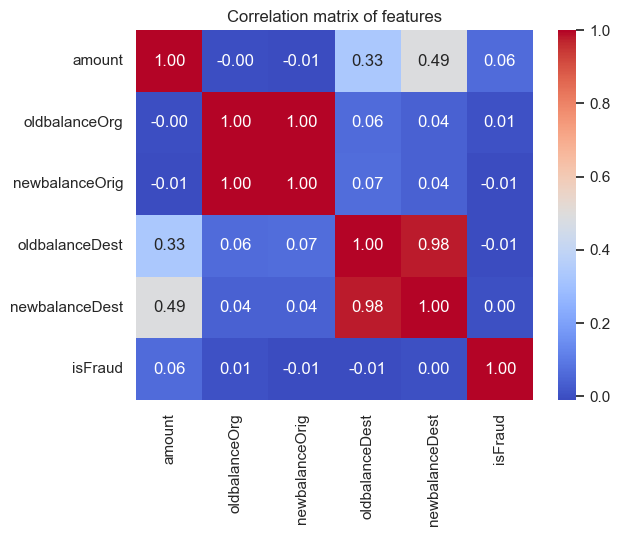

In [127]:
sns.heatmap(corr, annot=True, cmap="coolwarm",fmt=".2f")
plt.title("Correlation matrix of features")

In [128]:
zero_after_transfer = df[
    (df["oldbalanceOrg"]>0) &
    (df["newbalanceOrig"]==0) &
    (df["type"].isin(["TRANSFER", "CASH_OUT"]))
]
len(zero_after_transfer) #number of transactions with zero balance after transfer or cash_out

35691

In [129]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2100952,CASH_OUT,225179.84,C90800259,118260.0,0.0,C1803801192,12522641.14,12747820.98,0,0,-106919.84,0.000000e+00
564269,CASH_OUT,215520.27,C321680807,31398.0,0.0,C1391039094,428003.56,643523.83,0,0,-184122.27,-5.820766e-11
1100782,CASH_OUT,217684.00,C1261267302,88794.2,0.0,C11087455,974242.95,1191926.95,0,0,-128889.80,0.000000e+00
1624392,CASH_OUT,245037.23,C96925526,20683.0,0.0,C1447347286,299224.95,544262.18,0,0,-224354.23,5.820766e-11
929065,CASH_OUT,102405.27,C1759384359,19747.0,0.0,C1941916202,42525.01,144930.28,0,0,-82658.27,-7.275958e-12


In [130]:
df["isFraud"].value_counts()

isFraud
0    190641
1       238
Name: count, dtype: int64

Feature Engineering and Training/Testing of Models

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

### `train_test_split`
Splits the dataset into training and testing sets.  
Helps evaluate the model on unseen data and prevents overfitting.

### `StandardScaler`
Standardizes numerical features by scaling them to have mean 0 and standard deviation 1.  
Improves the performance of algorithms that are sensitive to feature scales.

### `LogisticRegression`
A supervised machine learning algorithm used for binary and multiclass classification.  
Predicts the probability of a data point belonging to a particular class.

### `classification_report`
Generates a summary of model performance including precision, recall, F1-score, and support.  
Provides detailed insights into classification accuracy.

### `confusion_matrix`
Displays the number of correct and incorrect predictions made by the model.  
Useful for understanding classification errors and model behavior.

### `Pipeline`
Combines multiple preprocessing and modeling steps into a single workflow.  
Ensures consistent and efficient execution of data processing and model training.

### `ColumnTransformer`
Applies different preprocessing techniques to different columns of the dataset.  
Useful when handling both numerical and categorical features together.

### `OneHotEncoder`
Converts categorical variables into numerical binary columns.  
Allows machine learning models to effectively use categorical data.

In [131]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
4598081,PAYMENT,14189.51,C1356511043,0.00,0.00,M1392805103,0.00,0.00,0,0,-14189.51,-14189.51
1384380,PAYMENT,15240.04,C1065349511,0.00,0.00,M1927004926,0.00,0.00,0,0,-15240.04,-15240.04
462527,PAYMENT,604.25,C1024666185,228485.00,227880.75,M292387302,0.00,0.00,0,0,0.00,-604.25
161964,CASH_OUT,477389.21,C412757352,0.00,0.00,C894315519,517257.87,435402.79,0,0,-477389.21,-559244.29
6008947,CASH_IN,356546.50,C126916680,1946815.39,2303361.89,C1669684987,2040513.51,1683967.01,0,0,-713093.00,-713093.00


In [132]:
df_model = df.drop(["nameOrig", "nameDest","isFlaggedFraud"], axis=1)
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
4598081,PAYMENT,14189.51,0.00,0.00,0.00,0.00,0,-14189.51,-14189.51
1384380,PAYMENT,15240.04,0.00,0.00,0.00,0.00,0,-15240.04,-15240.04
462527,PAYMENT,604.25,228485.00,227880.75,0.00,0.00,0,0.00,-604.25
161964,CASH_OUT,477389.21,0.00,0.00,517257.87,435402.79,0,-477389.21,-559244.29
6008947,CASH_IN,356546.50,1946815.39,2303361.89,2040513.51,1683967.01,0,-713093.00,-713093.00


In [150]:
df.head(2)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
4598081,PAYMENT,14189.51,C1356511043,0.0,0.0,M1392805103,0.0,0.0,0,0,-14189.51,-14189.51
1384380,PAYMENT,15240.04,C1065349511,0.0,0.0,M1927004926,0.0,0.0,0,0,-15240.04,-15240.04


In [151]:
categorical = ["type"]
numerical = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest","balanceDiffOrig","balanceDiffDest"]

In [152]:
#feature and target variable
y = df_model["isFraud"]
X = df_model.drop("isFraud", axis=1)

In [153]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [154]:
#preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder="drop"
)

In [155]:
#pipeline
pipeline1 = Pipeline([
    ("prep", preprocessor),
    ("clf",LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [156]:
pipeline2 = Pipeline([
    ("prep", preprocessor),
    ("clf",RandomForestClassifier( n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])

In [157]:
pipeline2.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['type','amount','oldbalanceOrg',...,'newbalanceDest','balanceDiffOrig', 'balanceDiffDest']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'

In [158]:
pipeline1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['type','amount','oldbalanceOrg',...,'newbalanceDest','balanceDiffOrig', 'balanceDiffDest']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'

In [159]:
y_pred =pipeline1.predict(X_test)

In [160]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     57193
           1       0.03      0.99      0.05        71

    accuracy                           0.96     57264
   macro avg       0.51      0.97      0.52     57264
weighted avg       1.00      0.96      0.98     57264



In [161]:
y_pred2 = pipeline2.predict(X_test)

In [162]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     57193
           1       1.00      1.00      1.00        71

    accuracy                           1.00     57264
   macro avg       1.00      1.00      1.00     57264
weighted avg       1.00      1.00      1.00     57264



In [163]:
pipeline2.score(X_test, y_test) * 100

100.0

In [164]:
pipeline1.predict_proba(X_test)[:,1] #probability of fraud for each transaction in test set

array([5.66921091e-01, 6.80602391e-06, 2.22583469e-07, ...,
       1.43776950e-01, 7.94283832e-06, 1.47566078e-04], shape=(57264,))

In [165]:
confusion_matrix(y_test,y_pred)

array([[54784,  2409],
       [    1,    70]])

In [166]:
pipeline1.score(X_test, y_test) * 100  #94.86 percent accuracy on test set

95.79142218496787

In [167]:
import joblib


joblib.dump(pipeline2, "fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']